In [ ]:
import numpy as np
import pandas as pd
import tensorflow as tf
import nltk
import seaborn as sns
import re
import matplotlib.pyplot as plt

from tensorflow.keras.layers import Embedding, Dense, LSTM, Dropout, Bidirectional
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.preprocessing.text import one_hot, Tokenizer
from tensorflow.keras.callbacks import ModelCheckpoint
from nltk.corpus import stopwords
from nltk.stem.porter import PorterStemmer
from sklearn import preprocessing
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


In [ ]:
df=pd.read_csv('../content/emotion.csv')
EMBEDDING_FILE= f'../content/glove.6B.100d.txt'
df.head()

,S.No,Emotion,Text
0,0,neutral,Why ?
1,1,joy,Sage Act upgrade on my to do list for tommorow.
2,2,sadness,ON THE WAY TO MY HOMEGIRL BABY FUNERAL!!! MAN ...
3,3,joy,Such an eye ! The true hazel eye-and so brill...
4,4,joy,@Iluvmiasantos ugh babe.. hugggzzz for u .! b...


/usr/local/lib/python3.7/dist-packages/seaborn/_decorators.py:43: FutureWarning: Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  FutureWarning


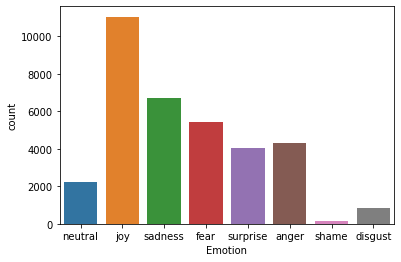

In [ ]:
#Target Classes
sns.countplot(df['Emotion'])

In [ ]:
df=df.dropna()
X=df.drop('Emotion',axis=1)
y=df['Emotion']

In [ ]:
messages=X.copy()
messages.reset_index(inplace=True)

In [ ]:
nltk.download('stopwords')
ps = PorterStemmer()
corpus = []
for i in range(0, len(messages)):
    review = re.sub('[^a-zA-Z]', ' ', messages['Text'][i])
    review = review.lower()
    review = review.split()
    review = [ps.stem(word) for word in review if not word in stopwords.words('english')]
    review = ' '.join(review)
    corpus.append(review)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [ ]:
corpus[:10]

['',
 'sage act upgrad list tommorow',
 'way homegirl babi funer man hate funer realli show bless',
 'eye true hazel eye brilliant regular featur open counten complexion oh bloom full health pretti height size firm upright figur health mere bloom air head glanc one hear sometim child pictur health alway give idea complet pictur grown health loveli',
 'iluvmiasanto ugh babe hugggzzz u babe naamaz nga ako e babe e despit nega ma pinaramdam fil ko ang',
 'expect extrem import phonecal minut terror opportun',
 'couldnt wait see live miss nh wasnt pain enuf suraj perform last gig delhi',
 'maken tip stop op een moment dat je het hele project wel ziet zitten nu du derestkomtlaterwel',
 'en dan krijg je ff een cadeautj van een tweep melik',
 'drummer boy bij op verzoek van biemoosterhof frankcornet welk uitvoer van wie']

In [ ]:
#Creating the dictionary with word as key and pretrained-value array as value
def get_coefs(word,*arr): return word, np.asarray(arr, dtype='float32')
embedding_index = dict(get_coefs(*o.strip().split()) for o in open(EMBEDDING_FILE))

#Calculate mean and std for the pretrained weights
all_emb = np.stack(embedding_index.values())
emb_mean,emb_std = all_emb.mean(), all_emb.std()
print(emb_mean,emb_std)

/usr/local/lib/python3.7/dist-packages/IPython/core/interactiveshell.py:2822: FutureWarning: arrays to stack must be passed as a "sequence" type such as list or tuple. Support for non-sequence iterables such as generators is deprecated as of NumPy 1.16 and will raise an error in the future.
  if self.run_code(code, result):


0.004451992 0.4081574


In [ ]:
voc_size=10000
embed_size=100

tokenizer = Tokenizer(num_words=voc_size)
tokenizer.fit_on_texts(list(corpus))
word_index = tokenizer.word_index
nb_words = min(voc_size, len(word_index))

#Initialize weight matrix for embedding layer
embedding_matrix = np.random.normal(emb_mean, emb_std, (nb_words, embed_size))

for word, i in word_index.items():
    if i >= voc_size: continue
    embedding_vector = embedding_index.get(word)
    if embedding_vector is not None: embedding_matrix[i] = embedding_vector

In [ ]:
#Contains the pretrained GloVe weights for the words
len(embedding_matrix)

10000

Process Input - Output Data

In [ ]:
#One hot representation for input
onehot_repr=[one_hot(words,voc_size)for words in corpus]

#Finding max words
l = 0
for x in corpus:
    l = max(l,len(x.split(' ')))

#Padding the sequences for input
sent_length= l
embedded_docs=pad_sequences(onehot_repr,padding='pre',maxlen=sent_length)
print(embedded_docs)


[[   0    0    0 ...    0    0    0]
 [   0    0    0 ...  885  610 2096]
 [   0    0    0 ... 4171 1362 4012]
 ...
 [   0    0    0 ... 5837  311 6112]
 [   0    0    0 ... 7204 8288 4005]
 [   0    0    0 ... 1028 1632 7691]]


In [ ]:
#Encoding the target outputs to integers
label_encoder = preprocessing.LabelEncoder()

X_final=np.array(embedded_docs)
y = label_encoder.fit_transform(y)
y_final=np.array(y)
print(y_final)

[4 3 5 ... 0 2 5]


In [ ]:
X_final.shape,y_final.shape

((34792, 100), (34792,))

In [ ]:
#Train-Test split
X_train, X_test, y_train, y_test = train_test_split(X_final, y_final,
                                                    test_size=0.2, random_state=42)
#Train-Validation split
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train,
                                                  test_size=0.1, random_state=21)

In [ ]:
# Creating model
model=Sequential()
model.add(Embedding(voc_size, embed_size, weights=[embedding_matrix]))
model.add(Dropout(0.3))
model.add(Bidirectional(LSTM(64)))
model.add(Dropout(0.3))
model.add(Dense(64, activation='relu',kernel_regularizer=tf.keras.regularizers.l1(0.01)))
model.add(Dropout(0.3))
model.add(Dense(8,activation='softmax'))
model.compile(loss='sparse_categorical_crossentropy',optimizer= tf.keras.optimizers.Adam(learning_rate=0.001),
              metrics=['accuracy'])
model.summary()

Model: "sequential_3"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
embedding_3 (Embedding)      (None, None, 100)         1000000   
_________________________________________________________________
dropout_9 (Dropout)          (None, None, 100)         0         
_________________________________________________________________
bidirectional_3 (Bidirection (None, 128)               84480     
_________________________________________________________________
dropout_10 (Dropout)         (None, 128)               0         
_________________________________________________________________
dense_6 (Dense)              (None, 64)                8256      
_________________________________________________________________
dropout_11 (Dropout)         (None, 64)                0         
_________________________________________________________________
dense_7 (Dense)              (None, 8)                

In [ ]:
model_save = ModelCheckpoint('weights.h5', save_best_only = True, save_weights_only = True, monitor = 'val_loss',
                             mode = 'min', verbose = 1)
history = model.fit(X_train,y_train,validation_data=(X_val,y_val),epochs=40,batch_size=64,callbacks = [model_save])

Epoch 1/40
392/392 [==============================] - 55s 133ms/step - loss: 3.0416 - accuracy: 0.3330 - val_loss: 1.7864 - val_accuracy: 0.3581

Epoch 00001: val_loss improved from inf to 1.78641, saving model to weights.h5
Epoch 2/40
392/392 [==============================] - 51s 130ms/step - loss: 1.7511 - accuracy: 0.3539 - val_loss: 1.7403 - val_accuracy: 0.3567

Epoch 00002: val_loss improved from 1.78641 to 1.74035, saving model to weights.h5
Epoch 3/40
392/392 [==============================] - 51s 130ms/step - loss: 1.7199 - accuracy: 0.3553 - val_loss: 1.7194 - val_accuracy: 0.3560

Epoch 00003: val_loss improved from 1.74035 to 1.71942, saving model to weights.h5
Epoch 4/40
392/392 [==============================] - 51s 130ms/step - loss: 1.6753 - accuracy: 0.3611 - val_loss: 1.6250 - val_accuracy: 0.4124

Epoch 00004: val_loss improved from 1.71942 to 1.62501, saving model to weights.h5
Epoch 5/40
392/392 [==============================] - 51s 130ms/step - loss: 1.5691 - ac

dict_keys(['loss', 'accuracy', 'val_loss', 'val_accuracy'])


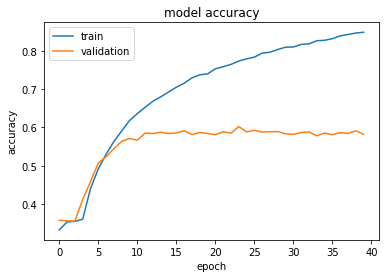

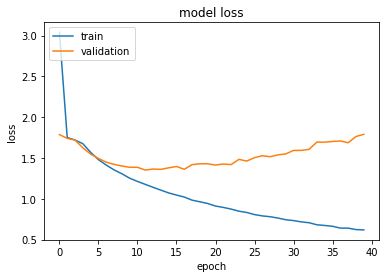

In [ ]:
print(history.history.keys())
#  "Accuracy"
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'validation'], loc='upper left')
plt.show()
# "Loss"
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'validation'], loc='upper left')
plt.show()

In [ ]:
#Load the best weights
model.load_weights('weights.h5')


In [ ]:
y_pred=model.predict_classes(X_test)
print(y_pred)

/usr/local/lib/python3.7/dist-packages/tensorflow/python/keras/engine/sequential.py:455: UserWarning: `model.predict_classes()` is deprecated and will be removed after 2021-01-01. Please use instead:* `np.argmax(model.predict(x), axis=-1)`,   if your model does multi-class classification   (e.g. if it uses a `softmax` last-layer activation).* `(model.predict(x) > 0.5).astype("int32")`,   if your model does binary classification   (e.g. if it uses a `sigmoid` last-layer activation).
  warnings.warn('`model.predict_classes()` is deprecated and '


[5 0 5 ... 3 2 2]


In [ ]:
#Accuracy score
print(accuracy_score(y_test,y_pred))

0.5870096278200891


In [ ]:
#Classification report
print(classification_report(y_test, y_pred, digits=5))

              precision    recall  f1-score   support

           0    0.56835   0.53708   0.55228       836
           1    0.00000   0.00000   0.00000       202
           2    0.62888   0.64312   0.63592      1104
           3    0.63397   0.70641   0.66823      2214
           4    0.75163   0.71726   0.73404       481
           5    0.51778   0.57046   0.54285      1327
           6    0.00000   0.00000   0.00000        23
           7    0.39877   0.33679   0.36517       772

    accuracy                        0.58701      6959
   macro avg    0.43742   0.43889   0.43731      6959
weighted avg    0.56467   0.58701   0.57459      6959



/usr/local/lib/python3.7/dist-packages/sklearn/metrics/_classification.py:1272: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


Confusion Matrix
AxesSubplot(0.125,0.125;0.62x0.755)


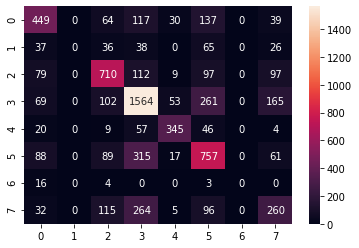

In [ ]:
#Confusion Matrix
print('Confusion Matrix')
print(sns.heatmap(confusion_matrix(y_test, y_pred),annot=True,fmt="d"))

Test on own

In [ ]:
#Mapping of target classes using label-encoder
le_name_mapping = dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)))
print(le_name_mapping)

{'anger': 0, 'disgust': 1, 'fear': 2, 'joy': 3, 'neutral': 4, 'sadness': 5, 'shame': 6, 'surprise': 7}


In [ ]:
#Example
def predict_emotion(stri):
    review = re.sub('[^a-zA-Z]', ' ', stri)
    review = review.lower()
    review = review.split()
    review = [ps.stem(word) for word in review if not word in stopwords.words('english')]
    review = ' '.join(review)
    onehot_repr = [one_hot(review,voc_size)]
    embed = pad_sequences(onehot_repr,padding='pre',maxlen=sent_length)
    predicti = model.predict(embed)
    return label_encoder.classes_[np.argmax(predicti)]

In [ ]:
predict_emotion('She was very happy with my gift.')

'joy'

In [ ]:
predict_emotion('Never let the sun go down on your anger.')

'anger'

In [ ]:
predict_emotion('The teacher is intimidating and scary')

'fear'